In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs # to make clusters

In [2]:
X,y = make_blobs(
    n_samples=1000,
    n_features=2, 
    centers=4,
    random_state=42
)

<Axes: >

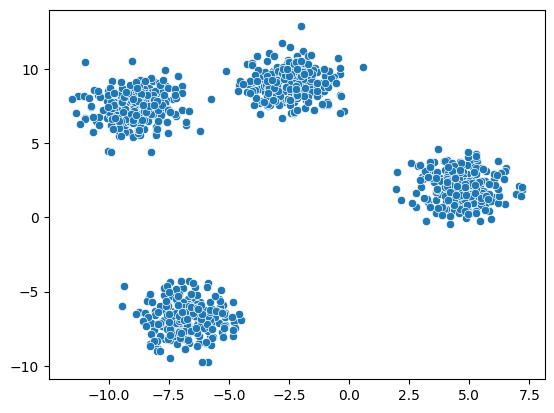

In [5]:
# Visualize

sns.scatterplot(x=X[:,0],y=X[:,1])

In [6]:
# K-means

from sklearn.cluster import KMeans

In [7]:
K = 4

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
)

In [8]:
labels = kmeans.fit_predict(X)
# label = cluster number

<Axes: >

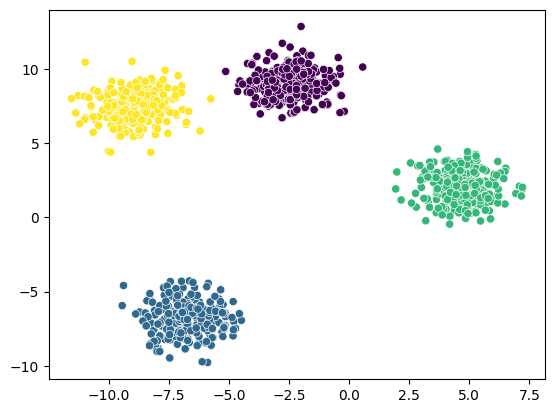

In [9]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=labels)

In [ ]:
### How to choose our K value ..
### elbow method , silhouette score

In [10]:
# elbow Method 
 
wcss = []

for k in range(1,21):

    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_) 

<Axes: >

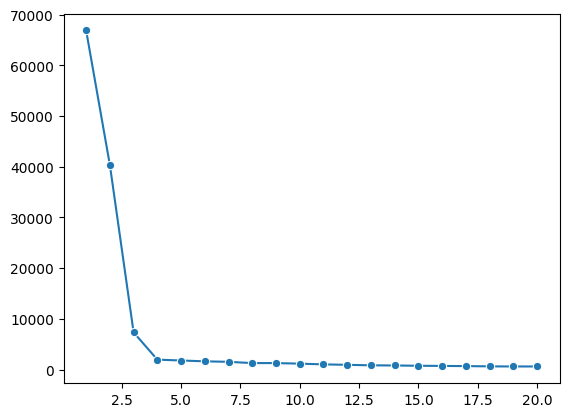

In [12]:
sns.lineplot(x=range(1,21),y=wcss,marker='o')

In [13]:
# Kneed Module 

from kneed import KneeLocator

In [14]:
knee = KneeLocator(range(1,21),wcss,curve="convex",direction="decreasing")

In [16]:
print("Optimal K-value :",knee.knee)

Optimal K-value : 4


In [17]:
### Silhoouette score

from sklearn.metrics import silhouette_score

In [19]:
ss = []

for k in range(2,21):

    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X,labels)

    ss.append(score)

<Axes: >

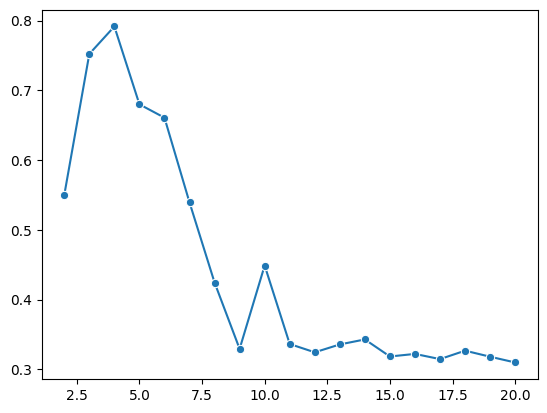

In [22]:
# plot - K & ss

sns.lineplot(x=range(2,21),y=ss,marker='o')

K-Means for IRIS Dataset

In [27]:
from sklearn.datasets import load_iris

In [28]:
iris = load_iris()

In [39]:
# X = pd.DataFrame(iris.data)
# X.columns = iris.feature_names
X = iris.data
y = iris.target

In [31]:
X.shape

(150, 4)

<Axes: >

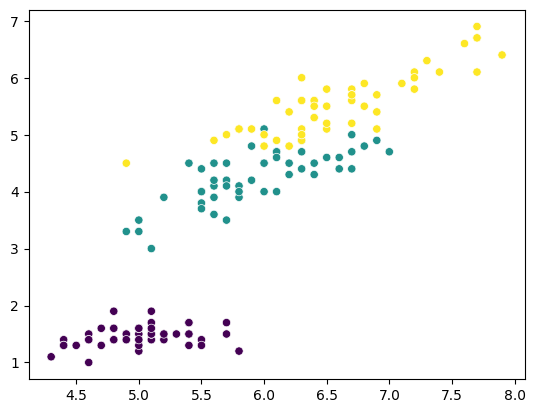

In [52]:
# visualize 

sns.scatterplot(x=X[:,0],y=X[:,2],c=y)

In [40]:
# scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)


In [54]:
# optional -  dimensionality reduction using PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(x_scaled)

In [41]:
from sklearn.cluster import KMeans

In [55]:
# Elbow method

wcss = []

for k in range(1,11):

    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

<Axes: >

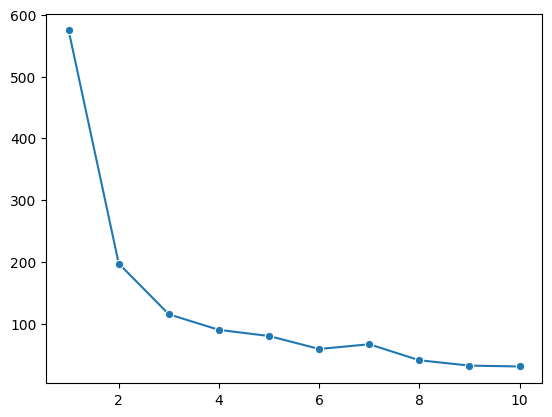

In [56]:
sns.lineplot(x = range(1,11),y=wcss,marker='o')

<Axes: >

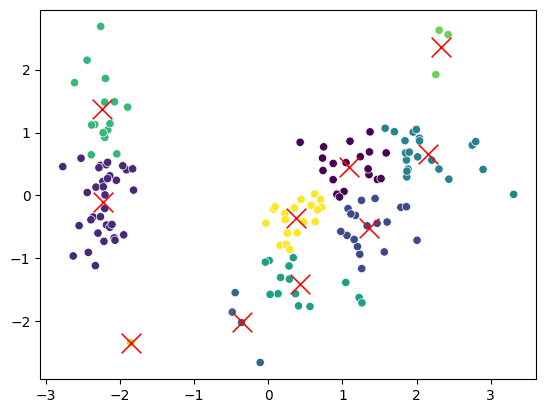

In [63]:
# K - means

kmens = KMeans(n_clusters=3,random_state=42)
labels = kmeans.fit_predict(pca_data)

# sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=labels)
sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker='x',c="red",s=200)

<Axes: >

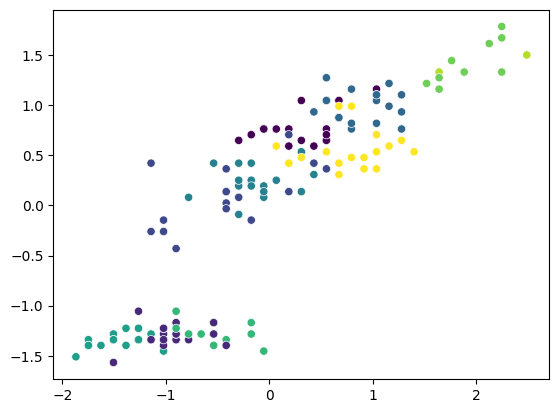

In [53]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=labels)